# Decision Tree & Neural Network


--- Decision Tree Model Evaluation ---
Best Parameters: {'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 2, 'max_features': None}
Cross-validation Accuracy: 0.8850 (+/- 0.0400)
Test Accuracy: 0.8890

Confusion Matrix:
[[95 10]
 [11 89]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8962    0.9048    0.9005       105
           1     0.8990    0.8900    0.8945       100

    accuracy                         0.8976       205
   macro avg     0.8976    0.8974    0.8975       205
weighted avg     0.8976    0.8976    0.8975       205

Epoch 1/10
41/41 [==============================] - 1s 13ms/step - loss: 0.6250 - accuracy: 0.6947 - val_loss: 0.4954 - val_accuracy: 0.8040
Epoch 2/10
41/41 [==============================] - 1s 15ms/step - loss: 0.5708 - accuracy: 0.7044 - val_loss: 0.4609 - val_accuracy: 0.8407
Epoch 3/10
41/41 [==============================] - 1s 13ms/step - loss: 0.5309 - accuracy: 0.7340 - val_loss: 0.4335 -

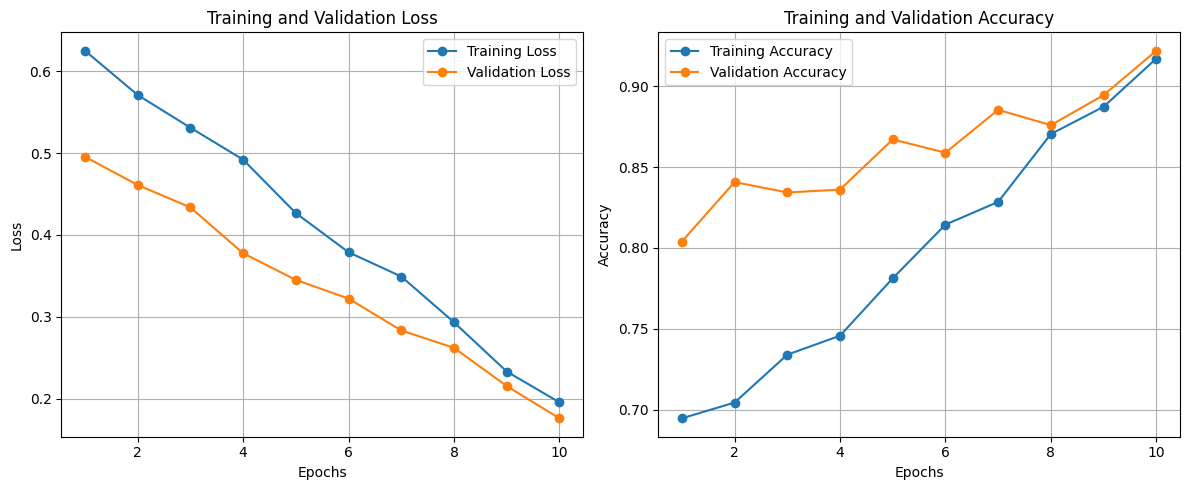


--- Neural Network Model Evaluation ---
Test Accuracy: 0.9100

Confusion Matrix:
[[97  8]
 [ 8 92]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9238    0.9238    0.9238       105
           1     0.9200    0.9200    0.9200       100

    accuracy                         0.9220       205
   macro avg     0.9219    0.9219    0.9219       205
weighted avg     0.9220    0.9220    0.9220       205



C:\Users\DerMokk\AppData\Local\Temp\ipykernel_5212\3516180233.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Decision Tree', 'Neural Network'], y=[dt_accuracy, nn_accuracy], palette='viridis')


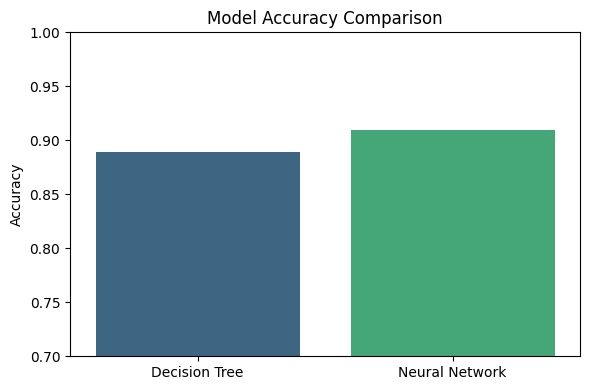

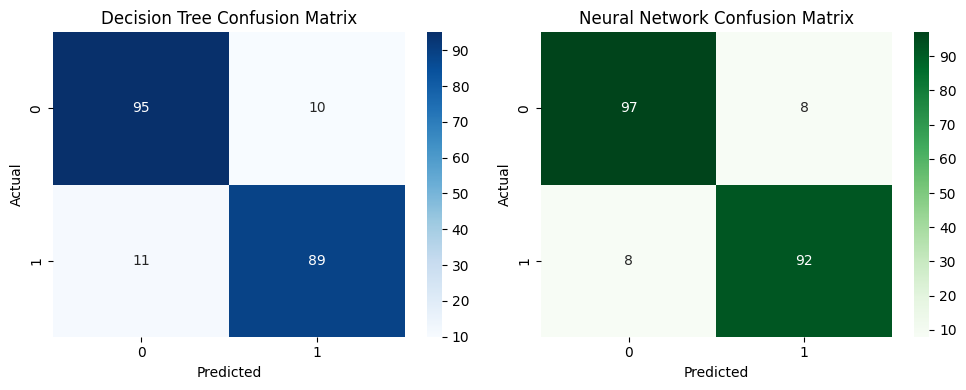


=== Model Comparison Summary ===
Decision Tree Accuracy: 0.8890
Neural Network Accuracy: 0.9100
The Neural Network outperformed the Decision Tree in terms of accuracy.

Confusion Matrix Differences:
Decision Tree Confusion Matrix:
 [[95 10]
 [11 89]]
Neural Network Confusion Matrix:
 [[97  8]
 [ 8 92]]
The Neural Network shows slightly better classification, as reflected in higher accuracy and confusion matrix values.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('heart.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Exploratory Data Analysis
plt.figure(figsize=(12, 8))

# Distribution of target variable
plt.subplot(2, 3, 1)
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')

# Age distribution by target
plt.subplot(2, 3, 2)
sns.histplot(data=df, x='age', hue='target', kde=True)
plt.title('Age Distribution by Target')

# Sex distribution by target
plt.subplot(2, 3, 3)
sns.countplot(x='sex', hue='target', data=df)
plt.title('Sex vs Target')

# Chest pain type by target
plt.subplot(2, 3, 4)
sns.countplot(x='cp', hue='target', data=df)
plt.title('Chest Pain Type vs Target')

# Correlation matrix
plt.subplot(2, 3, 5)
correlation = df.corr()
sns.heatmap(correlation['target'].to_frame(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Target')

plt.tight_layout()
plt.savefig('heart_eda.png')

# Data preparation
X = df.iloc[:, :13].values
y = df.iloc[:, 13].values

# Split the data with a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # نسبة البيانات المخصصة للاختبار (20%)
    random_state=42     # حالة عشوائية لضمان إعادة التجربة بنفس النتائج
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Decision Tree model with cross-validation
def evaluate_decision_tree():
    print("\n--- Decision Tree Model Evaluation ---")
    # Define parameter grid
    param_grid = {
        'criterion': ['gini', 'entropy'],  # معيار تقسيم العقد: 'gini' (مؤشر جيني) أو 'entropy' (الانتروبيا)
        'max_depth': [4, 6, 8, 10],        # أقصى عمق للشجرة (عدد المستويات)
        'min_samples_split': [2, 3, 5],    # الحد الأدنى لعدد العينات المطلوبة لتقسيم العقدة
        'max_features': [None, 'sqrt', 'log2'] # عدد الميزات المستخدمة عند كل تقسيم: None (كل الميزات)، 'sqrt' (الجذر التربيعي)، 'log2' (لوغاريتم 2)
    }

    # Grid search
    grid_search = GridSearchCV(
        DecisionTreeClassifier(random_state=42), # random_state: لضمان إعادة التجربة بنفس النتائج
        param_grid, 
        cv=5, # عدد الطيات في التحقق المتقاطع (Cross-validation)
        scoring='accuracy', # مقياس الأداء: الدقة
        n_jobs=-1 # استخدام جميع الأنوية المتاحة في المعالج
    )
    grid_search.fit(X_train, y_train)
    
    # Best parameters and model
    print("Best Parameters:", grid_search.best_params_)
    best_tree = grid_search.best_estimator_
    
    # Cross-validation score
    cv_scores = cross_val_score(best_tree, X_train, y_train, cv=10)
    print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # Evaluation on test set
    y_pred = best_tree.predict(X_test)
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return best_tree

# Neural Network model
def evaluate_neural_network():
    print("\n--- Neural Network Model Evaluation ---")
    # Use scaled features for neural network
    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50), # عدد الوحدات في الطبقات المخفية: طبقتان (100 و 50 وحدة)
        activation='relu',            # دالة التفعيل: 'relu' (دالة ريليو)
        solver='adam',                # خوارزمية التحسين: 'adam'
        alpha=0.0001,                 # معامل الانتظام (L2 regularization)
        batch_size='auto',            # حجم الدفعة: تلقائي (يتم تحديده تلقائياً)
        learning_rate='adaptive',     # نوع معدل التعلم: 'adaptive' (يتغير حسب الأداء)
        learning_rate_init=0.001,     # معدل التعلم الابتدائي
        max_iter=1000,                # الحد الأقصى لعدد التكرارات (epochs)
        random_state=42               # حالة عشوائية لضمان إعادة التجربة بنفس النتائج
    )
    
    mlp.fit(X_train_scaled, y_train)
    
    # Evaluation on test set
    y_pred = mlp.predict(X_test_scaled)
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return mlp

# Model comparison
def compare_models(models_dict):
    print("\n--- Model Comparison ---")
    results = {}
    
    for name, model in models_dict.items():
        if name == 'Neural Network':
            y_pred = model.predict(X_test_scaled)
        else:
            y_pred = model.predict(X_test)
            
        if name == 'XGBoost':
            y_pred = [round(value) for value in y_pred]
            
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = accuracy
        
    # Display results
    for name, accuracy in results.items():
        print(f"{name} Accuracy: {accuracy:.4f}")
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(results.keys()), y=list(results.values()))
    plt.ylim(0.7, 1.0)
    plt.title('Model Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.tight_layout()
    plt.savefig('model_comparison.png')

# Run the evaluation
if __name__ == "__main__":
    # Run all models
    decision_tree = evaluate_decision_tree()
    neural_network = evaluate_neural_network()
    
    # Compare models
    models = {
        'Decision Tree': decision_tree,
        'Neural Network': neural_network,
    }
    
    compare_models(models)

# SVM & CNN

--- Data Preprocessing ---
Original class distribution:
Counter({1: 526, 0: 499})

Applying SMOTE for oversampling...
Class distribution after SMOTE:
Counter({1: 526, 0: 526})

Size of X_train: (841, 13)
Size of X_test: (211, 13)
------------------------------

--- SVM Model Evaluation ---

Training SVM with linear kernel...
Accuracy with linear kernel: 0.8900
Confusion Matrix:
[[57 48]
 [48 57]]
Classification Report:
              precision    recall  f1-score   support

           0     0.5429    0.5429    0.5429       105
           1     0.5429    0.5429    0.5429       105

    accuracy                         0.5429       210
   macro avg     0.5429    0.5429    0.5429       210
weighted avg     0.5429    0.5429    0.5429       210


Training SVM with poly kernel...
Accuracy with poly kernel: 0.8950
Confusion Matrix:
[[53 52]
 [52 53]]
Classification Report:
              precision    recall  f1-score   support

           0     0.5048    0.5048    0.5048       105
           1 

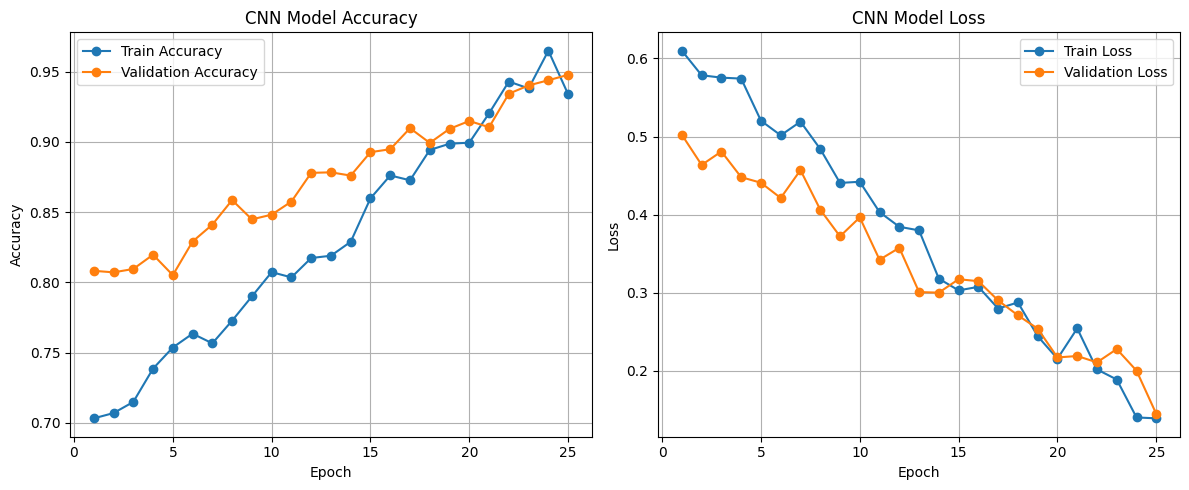


CNN Test accuracy: 0.9524
CNN Confusion Matrix:
[[100   5]
 [  5 100]]
CNN Classification Report:
              precision    recall  f1-score   support

           0     0.9524    0.9524    0.9524       105
           1     0.9524    0.9524    0.9524       105

    accuracy                         0.9524       210
   macro avg     0.9524    0.9524    0.9524       210
weighted avg     0.9524    0.9524    0.9524       210

------------------------------

--- Model Comparison ---
SVM Accuracy: 0.9020
CNN Accuracy: 0.9524


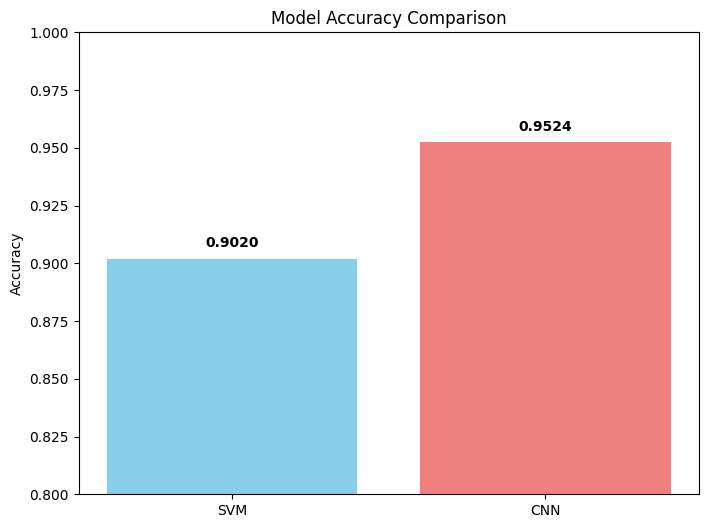


CNN model performs better.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from collections import Counter
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.layers import Flatten, Dense, Conv1D, MaxPool1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# 1. DATA PREPROCESSING
def preprocess_data(df, oversample=False, test_size=0.2):
    """
    Preprocess the heart disease dataset
    """
    # Separate features and target
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    
    print("Original class distribution:")
    counter_before = Counter(y)
    print(counter_before)
    
    # Apply SMOTE oversampling if requested
    if oversample:
        oversample = SMOTE(random_state=42)
        X, y = oversample.fit_resample(X, y)
        print("Class distribution after SMOTE:")
        counter_after = Counter(y)
        print(counter_after)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print('Size of X_train:', X_train.shape)
    print('Size of X_test:', X_test.shape)
    
    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test

# 2. SVM MODELS
def evaluate_svm_models(X_train_scaled, X_test_scaled, y_train, y_test):
    """
    Train and evaluate SVM models with different kernels
    """
    print("\n--- SVM Model Evaluation ---")
    
    # Define kernels to test
    kernels = ['linear', 'poly', 'rbf', 'sigmoid']
    
    # Train and evaluate SVM with different kernels
    results = {}
    best_accuracy = 0
    best_svm = None
    
    for kernel in kernels:
        print(f"\nTraining SVM with {kernel} kernel...")
        
        # Create and train SVM classifier
        svm = SVC(kernel=kernel, random_state=42, probability=True)
        svm.fit(X_train_scaled, y_train)
        
        # Predictions
        y_pred = svm.predict(X_test_scaled)
        
        # Evaluation
        accuracy = accuracy_score(y_test, y_pred)
        results[kernel] = accuracy
        
        print(f"Accuracy with {kernel} kernel: {accuracy:.4f}")
        print("Confusion Matrix:")
        cm = confusion_matrix(y_test, y_pred)
        print(cm)
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        
        # Keep track of the best model
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_svm = svm
    
    # Hyperparameter tuning for the best kernel
    best_kernel = max(results, key=results.get)
    print(f"\nPerforming hyperparameter tuning for SVM with {best_kernel} kernel...")
    
    # Define parameter grid
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]
    }
    
    # Grid search with cross-validation
    grid_search = GridSearchCV(
        SVC(kernel=best_kernel, probability=True, random_state=42),
        param_grid, 
        cv=5, 
        scoring='accuracy', 
        n_jobs=-1
    )
    grid_search.fit(X_train_scaled, y_train)
    
    print("Best parameters:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)
    
    # Evaluate best model
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    
    print("Final model accuracy:", accuracy_score(y_test, y_pred))
    print("Final confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Final classification report:")
    print(classification_report(y_test, y_pred))
    
    return best_model

# 3. CNN MODEL
def build_and_train_cnn(X_train_scaled, X_test_scaled, y_train, y_test):
    """
    Build and train a 1D CNN model for heart disease classification
    """
    print("\n--- CNN Model Evaluation ---")
    
    # Reshape input data for CNN
    X_train_cnn = np.array(X_train_scaled).reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
    X_test_cnn = np.array(X_test_scaled).reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
    
    print("X Train CNN shape:", X_train_cnn.shape)
    print("X Test CNN shape:", X_test_cnn.shape)
    
    # Check unique classes in target
    unique_classes = len(np.unique(y_train))
    print(f"Number of unique classes: {unique_classes}")
    
    # Define CNN model
    cnn_model = tf.keras.models.Sequential([
        # Convolutional layers
        Conv1D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=(X_train_scaled.shape[1], 1)),
        Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
        MaxPool1D(pool_size=2),
        
        # Second conv block
        Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
        MaxPool1D(pool_size=2),
        Dropout(0.3),
        
        # Flatten and dense layers
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        # For binary classification, use 1 unit with sigmoid activation
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model with appropriate loss function
    cnn_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',  # Binary classification
        metrics=['accuracy']
    )
    
    # Model summary
    cnn_model.summary()
    
    # Early stopping to prevent overfitting
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Train model
    history = cnn_model.fit(
        X_train_cnn, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test_cnn, y_test),
        callbacks=[early_stop]
    )
    
    # Plot training history
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='lower right')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.savefig('cnn_training_history.png')
    
    # Evaluate model
    loss, accuracy = cnn_model.evaluate(X_test_cnn, y_test)
    print(f"CNN Test accuracy: {accuracy:.4f}")
    
    # Get predictions
    y_pred_probs = cnn_model.predict(X_test_cnn)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    
    print("CNN Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("CNN Classification Report:")
    print(classification_report(y_test, y_pred))
    
    return cnn_model, history

# 4. MODEL COMPARISON
def compare_models(svm_model, cnn_model, X_test_scaled, y_test):
    """
    Compare SVM and CNN model performance
    """
    print("\n--- Model Comparison ---")
    
    # Reshape for CNN
    X_test_cnn = np.array(X_test_scaled).reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
    
    # Get predictions from SVM
    y_pred_svm = svm_model.predict(X_test_scaled)
    svm_accuracy = accuracy_score(y_test, y_pred_svm)
    
    # Get predictions from CNN
    y_pred_probs_cnn = cnn_model.predict(X_test_cnn)
    y_pred_cnn = (y_pred_probs_cnn > 0.5).astype(int).flatten()
    cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
    
    # Compare results
    print(f"SVM Accuracy: {svm_accuracy:.4f}")
    print(f"CNN Accuracy: {cnn_accuracy:.4f}")
    
    # Plot comparison
    models = ['SVM', 'CNN']
    accuracies = [svm_accuracy, cnn_accuracy]
    
    plt.figure(figsize=(8, 6))
    plt.bar(models, accuracies, color=['skyblue', 'lightcoral'])
    plt.ylim(0.7, 1.0)
    plt.title('Model Accuracy Comparison')
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    
    # Add accuracy values on top of bars
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
    
    plt.savefig('model_comparison.png')
    
    # Return the best model name
    if cnn_accuracy > svm_accuracy:
        print("\nCNN model performs better.")
        return "CNN"
    else:
        print("\nSVM model performs better.")
        return "SVM"

# 5. MAIN EXECUTION
def main():
    """
    Main function to execute the heart disease classification pipeline
    """
    # Load the dataset
    df = pd.read_csv('heart.csv')
    
    # Display basic info
    print("Dataset Shape:", df.shape)
    print("\nFirst 5 rows:")
    print(df.head())
    
    # Check class distribution
    print("\nTarget distribution:")
    print(df['target'].value_counts())
    
    # Preprocess data
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = preprocess_data(df, oversample=True)
    
    # Train and evaluate SVM models
    best_svm = evaluate_svm_models(X_train_scaled, X_test_scaled, y_train, y_test)
    
    # Train and evaluate CNN model
    cnn_model, history = build_and_train_cnn(X_train_scaled, X_test_scaled, y_train, y_test)
    
    # Compare models
    best_model_name = compare_models(best_svm, cnn_model, X_test_scaled, y_test)
    
    print(f"\nBest model is {best_model_name}")

# Run the main function
if __name__ == "__main__":
    main()